In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Connect and pull the engineered matrix
con = duckdb.connect('../data/processed/biocascade.db')
df = con.execute("SELECT * FROM feature_matrix_raw").df()

print(f"✅ Feature matrix loaded: {df.shape[0]} patients, {df.shape[1]} features.")
df[['pulse_pressure', 'log_triglycerides', 'vasc_metabolic_load']].head()

✅ Feature matrix loaded: 4571 patients, 17 features.


,pulse_pressure,log_triglycerides,vasc_metabolic_load
0,38.0,4.532599,582.4
1,54.0,4.890349,756.0
2,40.0,4.094345,615.6
3,44.0,4.828314,604.8
4,34.0,4.564348,582.4


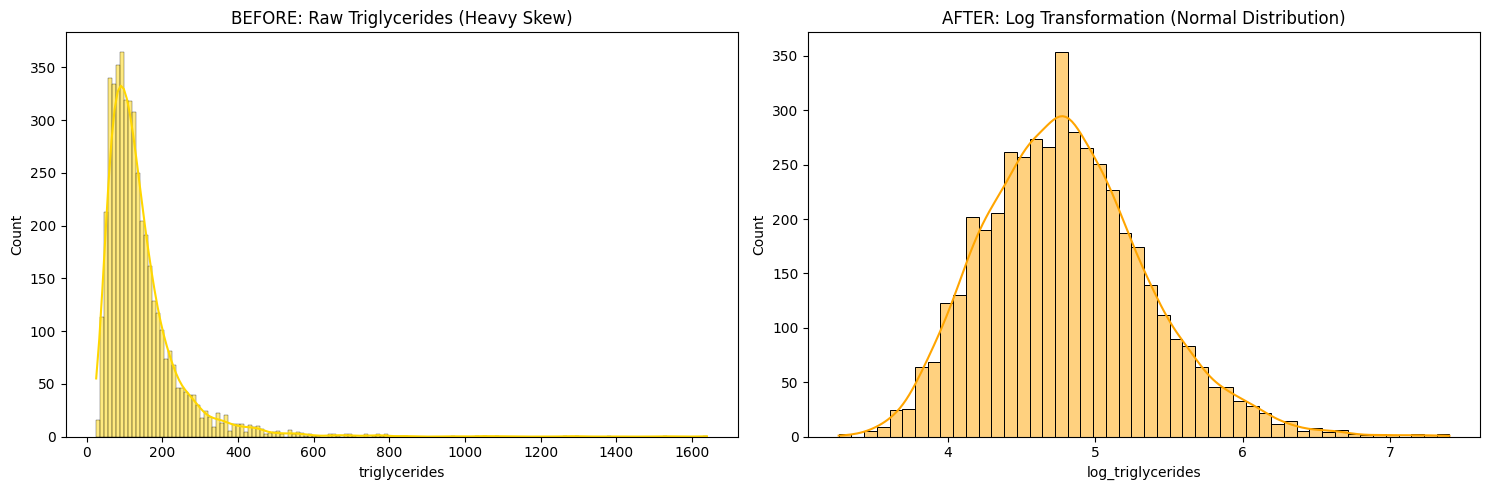

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Raw Skewed Data
sns.histplot(df['triglycerides'], kde=True, ax=axes[0], color='gold')
axes[0].set_title('BEFORE: Raw Triglycerides (Heavy Skew)')

# Plot 2: Normalized Log Data
sns.histplot(df['log_triglycerides'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('AFTER: Log Transformation (Normal Distribution)')

plt.tight_layout()
plt.show()

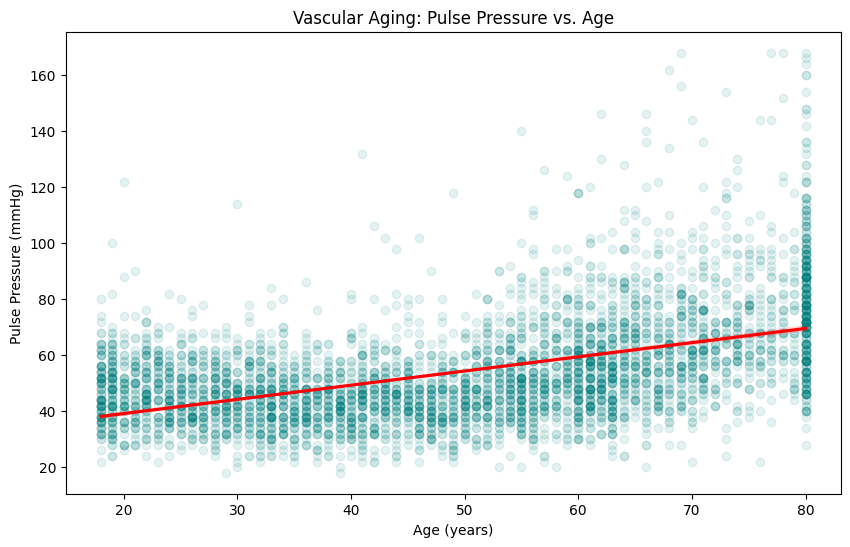

In [3]:
# Scatter plot to show relationship between Age and Pulse Pressure
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='age', y='pulse_pressure', 
            scatter_kws={'alpha':0.1, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title("Vascular Aging: Pulse Pressure vs. Age")
plt.xlabel("Age (years)")
plt.ylabel("Pulse Pressure (mmHg)")
plt.show()

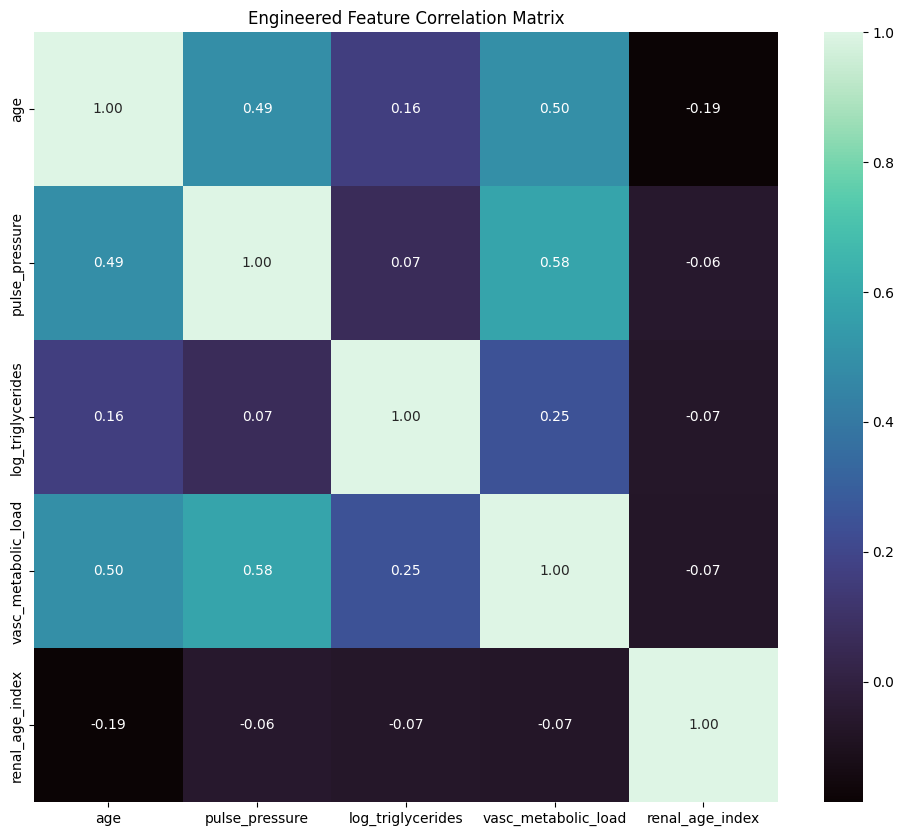

In [4]:
# Checking for redundancy in our engineered features
plt.figure(figsize=(12, 10))
engineered_cols = ['age', 'pulse_pressure', 'log_triglycerides', 'vasc_metabolic_load', 'renal_age_index']
corr = df[engineered_cols].corr()

sns.heatmap(corr, annot=True, cmap='mako', fmt=".2f")
plt.title("Engineered Feature Correlation Matrix")
plt.show()